# Task #2 - Ultrasound Task

## Team Members:

\begin{array}{ccc}
Name&BN\\
Ahmed\ Kamal&4\\
Abdelrahman\ Shawky&35\\
Ziyad\ Hossam&25\\
Omar\ Abdel_Naser&44\\
Hazem\ Raafat&14\\
\end{array}

# Installing Our Package / Toolbox: PyMust

### PyMust: is a Python reimplementation of the **MUST** ultrasound toolbox for synthetic image generation and reconstruction

## Importing our Libraries

In [ ]:
import pymust as pymust
import numpy as np
import matplotlib.pyplot as plt

## Setup Parameters

# Initialize Transducer (Phased Array Transducer)
Download the properties of a 2.7-MHz 64-element cardiac phased array in a structure param by using GETPARAM.

In [ ]:
# Initialize transducer
param = pymust.getparam('P4-2v')

# Single Focus Point Pressure Field

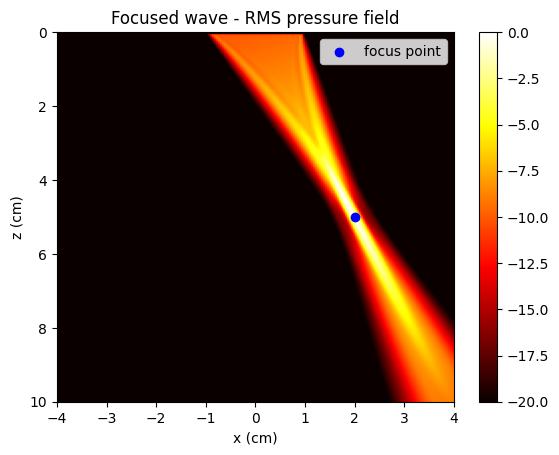

In [ ]:
# Choose a focus location at xf = 2 cm, zf = 5 cm.
xf = 2e-2
zf = 5e-2 # focus position (in m)

# Obtain the corresponding transmit time delays (in s).
txdel = pymust.txdelay(xf, zf, param)


# Simulate the pressure field by using PFIELD.
# First define an image grid.
x = np.linspace(-4e-2, 4e-2, 200); # in m
z = np.linspace(0, 10e-2, 200); # in m
x, z = np.meshgrid(x, z)
y = np.zeros_like(x)

# The function PFIELD yields the root-mean-square (RMS) pressure field.
P, _, _  = pymust.pfield(x,y, z,txdel,param)

# Display the acoustic pressure field.
plt.imshow(20*np.log10(P/np.max(P)), extent = np.array([x[0,0], x[-1,-1], z[-1,-1], z[0,0]])*1e2, cmap = 'hot', aspect = 'auto')
plt.colorbar()
plt.clim(-20, 0)
plt.xlabel('x (cm)')
plt.ylabel('z (cm)')
plt.title('Focused wave - RMS pressure field')
plt.scatter(xf*1e2, 10-zf*1e2, c = 'b', label = 'focus point')
plt.legend()

# Diverging Wave Pressure Field

In [ ]:
def drawDiverging(width=20, tilt=0):
    # Calculate the transmit delays to generate a 75-degrees wide circular wave. Use TXDELAY.
    width = width / 180 * np.pi # width angle in rad
    tilt = tilt / 180 * np.pi # tilt angle in rad
    txdel = pymust.txdelay(param, tilt, width) #% in s


    # Apodization function
    param.TXApodization = np.cos(np.linspace(-3*np.pi/8,3*np.pi/8,64))

    # Simulate the pressure field by using PFIELD.
    # First define an image grid.
    x = np.linspace(-4e-2, 4e-2, 200); # in m
    z = np.linspace(0, 10e-2, 200); # in m
    x, z = np.meshgrid(x, z)
    y = np.zeros_like(x)

    # The function PFIELD yields the root-mean-square (RMS) pressure field.
    P,_,_ = pymust.pfield(x, y, z, txdel, param)

    # Display the acoustic pressure field.
    plt.imshow(20*np.log10(P/np.max(P)), extent = np.array([x[0,0], x[-1,-1], z[-1,-1], z[0,0]])*1e2, cmap = 'hot')
    plt.clim(-20, 0) #dynamic range = [-20,0] dB
    plt.axis('equal')
    c = plt.colorbar()
    plt.xlabel('x (cm)')
    plt.ylabel('z (cm)')
    plt.title('Diverging wave - RMS pressure field')
    plt.show()

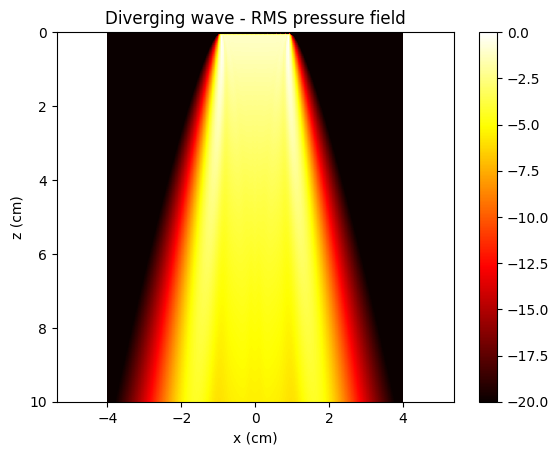

In [ ]:
drawDiverging(20, 0)

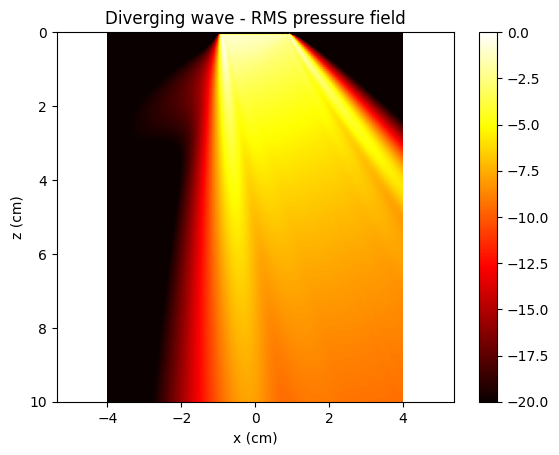

In [ ]:
drawDiverging(50,20)

# Multi-Focus Point Pressure Field


Text(0.5, 1.0, 'MLT - RMS pressure field')

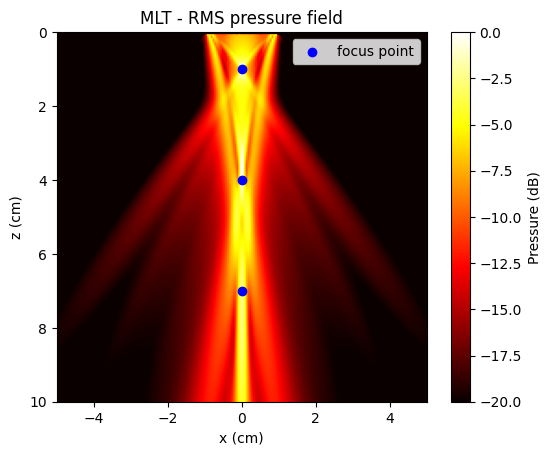

In [ ]:
# Define the TX delays for a 3-MLT transmit sequence.
x0 = 2e-2 # in m
z0 = 5e-2; # in m
xf = np.array([0 for _ in range(3)]); # transmit aperture positions (in m)
zf = np.array([0.01 + i*(0.03) for i in range(3)]); # focus points (in m)
txdel = pymust.txdelay(xf, zf, param); # in s
# Simulate the pressure field with PFIELD.

# Define the image grid.
x = np.linspace(-5e-2,5e-2,200); # in m
z = np.linspace(0,10e-2,200); # in m
x,z = np.meshgrid(x,z); # image grid
y = np.zeros(x.shape)

# Use PFIELD to obtain the RMS pressure field.
P,_,_ = pymust.pfield(x,y,z,txdel,param)

# Display the pressure field.
plt.imshow(20*np.log10(P/np.max(P)), extent = np.array([x[0,0], x[-1,-1], z[-1,-1], z[0,0]])*1e2, cmap = 'hot')
cbar = plt.colorbar()
cbar.set_label('Pressure (dB)')
plt.clim(-20, 0)
plt.scatter(xf*1e2,zf*1e2,c = 'b', label = 'focus point')
plt.legend()
plt.xlabel('x (cm)')
plt.ylabel('z (cm)')
plt.title('MLT - RMS pressure field')
